# Implementation of K-Means clustering MD trajectory data

In [10]:
import numpy as np
from ase.io.lammpsrun import read_lammps_dump_text
from ase.io.lammpsdata import read_lammps_data
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from gendyndiff.diffusion.data.batched_data import CustomCrystalDataset
from gendyndiff.common.data.collate import CustomCollate

In [11]:
dump_file_path = "/home/agore/GenDynDiff/datasets/SrTiO3/dump.NPT"
def read_lammps_types(dump_file_path):
    all_types = []  # Will hold types from all timesteps
    type_to_atomic_number = {1: 38, 2: 22, 3: 8}
    # Define mapping from atomic numbers to element symbols
    atomic_number_to_symbol = {38: "Sr", 22: "Ti", 8: "O"}

    with open(dump_file_path, 'r') as f:
        atoms_section = False
        atom_id_to_type = {}  # Reset for each timestep

        for line in f:
            line = line.strip()

            if line.startswith("ITEM: TIMESTEP") and atom_id_to_type:
                sorted_types = [atom_id_to_type[id] for id in sorted(atom_id_to_type.keys())]
                all_types.extend(sorted_types)
                atom_id_to_type = {}  # Reset for next timestep
                atoms_section = False

            # Check if we've reached the atoms section
            if line.startswith("ITEM: ATOMS"):
                atoms_section = True
                continue

            # Process atom data lines
            if atoms_section and line and not line.startswith("ITEM:"):
                columns = line.split()
                if len(columns) > 1:
                    atom_id = int(columns[0])
                    type_val = float(columns[1])
                    if type_val <= 3.0:
                        mapped_val = type_to_atomic_number.get(int(type_val))
                        if mapped_val is not None:
                            atom_id_to_type[atom_id] = mapped_val

        # Don't forget to process the last timestep
        if atom_id_to_type:
            sorted_types = [atom_id_to_type[id] for id in sorted(atom_id_to_type.keys())]
            all_types.extend(sorted_types)

    # Create a new array with element symbols
    all_symbols = [atomic_number_to_symbol[atomic_num] for atomic_num in all_types]

    return all_types, all_symbols

atom_types,atom_symbols = read_lammps_types(dump_file_path)
print(atom_types)
print(atom_symbols)


[38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8,

In [12]:
dump_file_path = "/home/agore/GenDynDiff/datasets/SrTiO3/dump.NPT"
cfg_file_path = "/home/agore/GenDynDiff/datasets/SrTiO3/SrTiO3_555_5pO_5pSr.cfg"

# Load dataset using CustomCrystalDataset class
custom_collate = CustomCollate()
datasets = CustomCrystalDataset.from_dump_file(dump_file_path, cfg_file_path)

oxygen_trajectories = {}
n_clusters = 50

# Iterate through each timestep's dataset
for timestep_idx, dataset in enumerate(datasets):
    print(f"Timestep {timestep_idx + 1}:")
    batched_data = custom_collate([dataset])

    num_atoms = batched_data.atoms.size(0)
    print(num_atoms)

    for i in range(num_atoms):
        element = batched_data.elements[i].item()
        if element == 8:
            position = batched_data.positions[i].tolist()
            atom_id = f"{i}"
            if atom_id not in oxygen_trajectories:
                oxygen_trajectories[atom_id] = []

            oxygen_trajectories[atom_id].append(position)



Timestep 1:
625
Timestep 2:
625
Timestep 3:
625
Timestep 4:
625
Timestep 5:
625
Timestep 6:
625
Timestep 7:
625
Timestep 8:
625
Timestep 9:
625
Timestep 10:
625
Timestep 11:
625
Timestep 12:
625
Timestep 13:
625
Timestep 14:
625
Timestep 15:
625
Timestep 16:
625
Timestep 17:
625
Timestep 18:
625
Timestep 19:
625
Timestep 20:
625
Timestep 21:
625
Timestep 22:
625
Timestep 23:
625
Timestep 24:
625
Timestep 25:
625
Timestep 26:
625
Timestep 27:
625
Timestep 28:
625
Timestep 29:
625
Timestep 30:
625
Timestep 31:
625
Timestep 32:
625
Timestep 33:
625
Timestep 34:
625
Timestep 35:
625
Timestep 36:
625
Timestep 37:
625
Timestep 38:
625
Timestep 39:
625
Timestep 40:
625
Timestep 41:
625
Timestep 42:
625
Timestep 43:
625
Timestep 44:
625
Timestep 45:
625
Timestep 46:
625
Timestep 47:
625
Timestep 48:
625
Timestep 49:
625
Timestep 50:
625
Timestep 51:
625
Timestep 52:
625
Timestep 53:
625
Timestep 54:
625
Timestep 55:
625
Timestep 56:
625
Timestep 57:
625
Timestep 58:
625
Timestep 59:
625
Timest

In [13]:
all_positions = []
atom_to_positions = {}

for atom_id, positions in oxygen_trajectories.items():
    all_positions.extend(positions)
    atom_to_positions[atom_id] = np.array(positions)

all_positions = np.array(all_positions)
print(all_positions)

[[-7.82539988 -9.78174973 -7.82539988]
 [-7.63261986 -9.88269997 -7.8741498 ]
 [-7.99545002 -9.85276031 -7.87669992]
 ...
 [ 5.9231801   7.88349009  7.65092993]
 [ 5.91053009  7.8273201   8.03682041]
 [ 5.98940992  7.96085978  7.87005997]]


In [14]:
#actual k-means clustering algorithm

kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(all_positions)
cluster_centers = kmeans.cluster_centers_

atom_labels = {}
for atom_id, positions in atom_to_positions.items():
    labels = kmeans.predict(positions)
    atom_labels[atom_id] = labels

In [15]:
from collections import defaultdict

jumps = defaultdict(int)
dwell_times = defaultdict(list)

for atom_id, labels in atom_labels.items():
    if len(labels) < 2:
        continue

    current_cluster = labels[0]
    dwell_start = 0

    for i in range(1, len(labels)):
        if labels[i] != current_cluster:
            # Record jump from one site to another
            jumps[(current_cluster, labels[i])] += 1

            # Record how long oxygen stayed at the site
            dwell_time = i - dwell_start
            dwell_times[current_cluster].append(dwell_time)

            # Update tracking
            current_cluster = labels[i]
            dwell_start = i

    dwell_time = len(labels) - dwell_start
    dwell_times[current_cluster].append(dwell_time)

In [16]:
print(f"Found {len(oxygen_trajectories)} oxygen atoms")
print(f"Identified {len(cluster_centers)} potential oxygen sites")
print(f"Recorded {len(jumps)} different jump types between sites")

print("\nMost common jumps:")
sorted_jumps = sorted(jumps.items(), key=lambda x: x[1], reverse=True)
for (from_site, to_site), count in sorted_jumps[:5]:
    print(f"From site {from_site} to site {to_site}: {count} jumps")

print("\nAverage dwell times at each site:")
for site, times in dwell_times.items():
    if times:
        avg_time = sum(times) / len(times)
        print(f"Site {site}: {avg_time:.2f} timesteps")

Found 375 oxygen atoms
Identified 50 potential oxygen sites
Recorded 177 different jump types between sites

Most common jumps:
From site 36 to site 33: 49 jumps
From site 33 to site 36: 46 jumps
From site 37 to site 42: 46 jumps
From site 42 to site 37: 44 jumps
From site 1 to site 46: 35 jumps

Average dwell times at each site:
Site 36: 8.45 timesteps
Site 19: 8.51 timesteps
Site 33: 5.36 timesteps
Site 48: 7.48 timesteps
Site 43: 9.33 timesteps
Site 24: 9.97 timesteps
Site 16: 9.96 timesteps
Site 17: 7.94 timesteps
Site 31: 9.30 timesteps
Site 45: 9.03 timesteps
Site 23: 9.42 timesteps
Site 5: 12.09 timesteps
Site 2: 16.73 timesteps
Site 30: 11.74 timesteps
Site 18: 14.51 timesteps
Site 14: 7.45 timesteps
Site 28: 13.05 timesteps
Site 44: 8.52 timesteps
Site 21: 11.70 timesteps
Site 47: 11.02 timesteps
Site 37: 10.95 timesteps
Site 41: 101.00 timesteps
Site 10: 9.46 timesteps
Site 8: 29.92 timesteps
Site 42: 6.88 timesteps
Site 11: 6.37 timesteps
Site 4: 7.02 timesteps
Site 12: 10.0

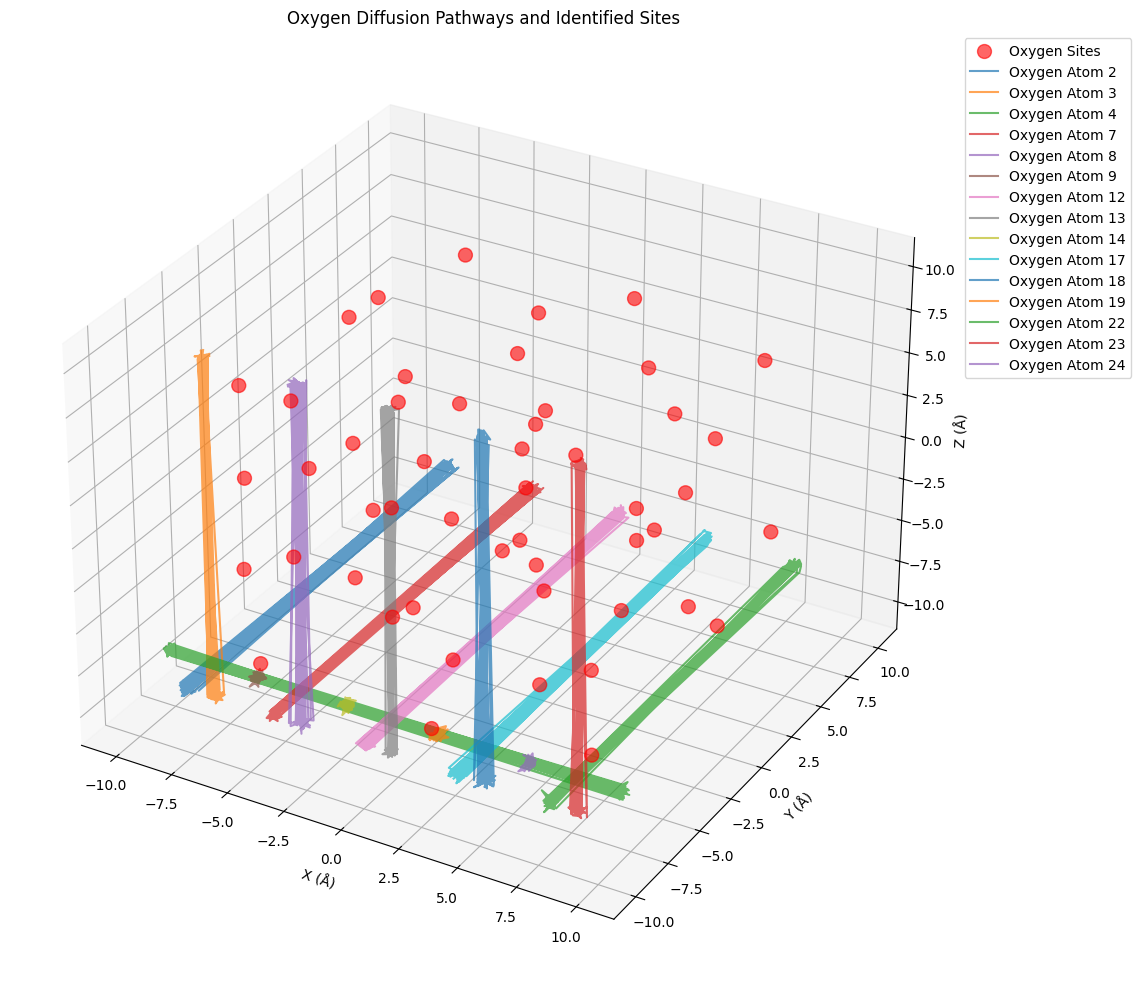

In [21]:
 import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors
from matplotlib.lines import Line2D

# 1. 3D visualization of cluster centers and sample trajectories
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot cluster centers (oxygen sites)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], cluster_centers[:, 2],
           s=100, c='r', marker='o', alpha=0.6, label='Oxygen Sites')

# Plot a few sample trajectories
colors = list(colors.TABLEAU_COLORS)
sample_atoms = min(15, len(oxygen_trajectories))
for i, atom_id in enumerate(list(oxygen_trajectories.keys())[:sample_atoms]):
    positions = np.array(oxygen_trajectories[atom_id])
    color = colors[i % len(colors)]
    ax.plot(positions[:, 0], positions[:, 1], positions[:, 2],
            c=color, linestyle='-', alpha=0.7, linewidth=1.5,
            label=f'Oxygen Atom {atom_id}')

ax.set_xlabel('X (Å)')
ax.set_ylabel('Y (Å)')
ax.set_zlabel('Z (Å)')
ax.set_title('Oxygen Diffusion Pathways and Identified Sites')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('oxygen_diffusion_3d.png', dpi=300, bbox_inches='tight')
plt.show()